Using the  Medical Insurance dataset, perform data preprocessing including handling missing values, encoding categorical variables, and feature scaling, and implement Multiple Linear Regression to predict the dependent variable using multiple independent variables, and compare the performance of the model with the simple linear regression model using metrics such as MAE, MSE, RMSE, and R² score.

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [ ]:
df=pd.read_csv('/content/medical-charges (1).csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


The dataset has no missing data

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df= pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


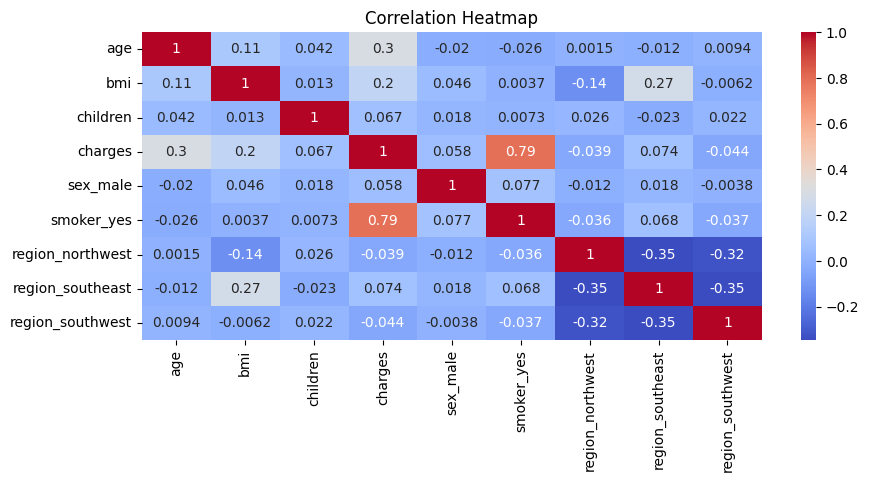

In [ ]:
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

correlation heatmap visualize the relationships between different variables.It displays the Pearson correlation coefficients, ranging from -1 to 1, indicating the strength and direction of the linear relationship between pairs of features.

Since we have more than 1 independent variable.We performe Multiple Linear Regression keeping 1 dependent (Charges) and rest independent

In [ ]:
# Defining the dependent and independent variables
x=df.drop("charges",axis=1)
y=df["charges"]
x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [ ]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#Feature scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
model.coef_

array([3472.97555343, 1927.82825101,  636.5011853 ,  -50.74967467,
       9234.34248701, -168.94443943, -371.7808097 , -284.61039635])

The coefficient values show that smoking status, age, and BMI significantly increase medical insurance charges, while gender and region have relatively smaller effects on the predicted cost.

In [ ]:
model.intercept_

np.float64(13030.203369289053)

The intercept value 13030.20 represents the baseline medical insurance charge when all independent variables are zero.

In [ ]:
#prediction
y_pred=model.predict(x_test_scaled)

In [ ]:
#R squared value
r2 = r2_score(y_test, y_pred=y_pred)
r2

0.8069287081198011

R squared value of 0.806 shows the model has good predictive power.

That is the model is good at predicting the dependent variable.

In [ ]:
#Mean absolute eroor
mae = mean_absolute_error(y_test, y_pred)
mae

4177.045561036326

In [ ]:
#Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
mse

35478020.675235614

This means the model's prediction is about 5956 units away from the actual insurance charges on average.

In [ ]:
#Root mean square
rmse = np.sqrt(mse)
rmse

np.float64(5956.342894363589)

The RMSE value of 5956.34 indicates that the model’s predictions deviate from the actual medical insurance charges by approximately 5956 units on average.

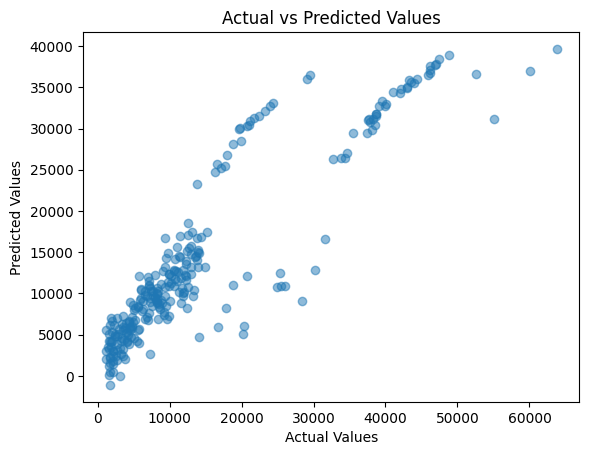

In [ ]:
plt.scatter(y_test,y_pred,alpha=.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

The Multiple Linear Regression model predicts medical insurance charges using several factors such as age, BMI, smoking status, and region. The model achieved an R² score of around 0.806, indicating that it explains about 80% of the variation in insurance charges, and it performs better than the Simple Linear Regression model.